<a href="https://colab.research.google.com/github/Thabanya/Experimentation-and-uplift-modeling/blob/main/Experimentation_and_uplift_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM STATEMENT:

Companies send promotional emails to customers to increase purchases.
However, not all customers respond positively—some ignore emails, and some may even be negatively affected.
This project aims to evaluate whether sending promotional emails increases customer conversions and to identify which customers should be targeted to maximize effectiveness.

Exploratory Data Analysis:


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Hillstroam email marketing dataset.csv to Hillstroam email marketing dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("Hillstroam email marketing dataset.csv")
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


In [4]:
df['zip_code'] = df['zip_code'].replace('Surburban', 'Suburban')
df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

In [5]:
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment
0,10,2) $100 - $200,142.44,1,0,Suburban,0,Phone,Womens E-Mail,0,0,0.0,1
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
2,7,2) $100 - $200,180.65,0,1,Suburban,1,Web,Womens E-Mail,0,0,0.0,1
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1


Summary statistics:

In [6]:
df.describe()

,recency,history,mens,womens,newbie,visit,conversion,spend,treatment
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908,0.667094
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448,0.471257
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000,1.000000


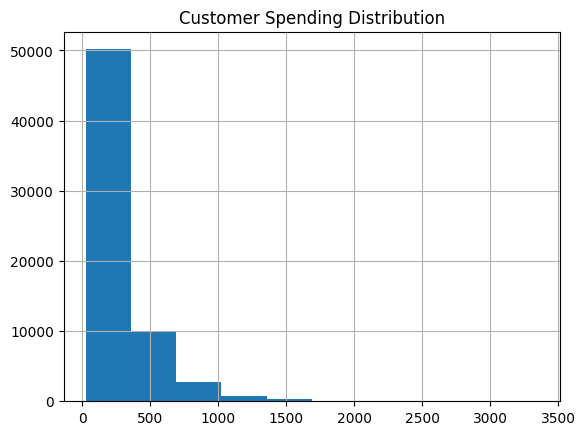

In [7]:
import matplotlib.pyplot as plt

df['history'].hist()
plt.title("Customer Spending Distribution")
plt.show()

In [8]:
df['segment'].value_counts()

,count
segment,
Womens E-Mail,21387
Mens E-Mail,21307
No E-Mail,21306


In [9]:
df['conversion'].mean()

np.float64(0.00903125)

In [10]:
df.groupby('segment')['conversion'].mean()

,conversion
segment,
Mens E-Mail,0.012531
No E-Mail,0.005726
Womens E-Mail,0.008837


In [11]:
df.groupby('newbie')['conversion'].mean()


,conversion
newbie,
0,0.010108
1,0.007964


In [12]:
df.groupby('channel')['conversion'].mean()

,conversion
channel,
Multichannel,0.012626
Phone,0.007744
Web,0.009321


In [13]:

df.groupby('history_segment')['conversion'].mean()

,conversion
history_segment,
1) $0 - $100,0.007140
2) $100 - $200,0.006945
3) $200 - $350,0.009521
4) $350 - $500,0.013419
5) $500 - $750,0.011607
"6) $750 - $1,000",0.014524
"7) $1,000 +",0.021407


A/B Testing:
Did sending emails increase conversions?
Null Hypothesis (H₀): Email has no effect on conversion
Alternative Hypothesis (H₁): Email changes conversion rate

In [14]:
df.groupby('treatment')['conversion'].agg(['mean', 'count'])

,mean,count
treatment,,
0,0.005726,21306
1,0.010681,42694


In [15]:
from statsmodels.stats.proportion import proportions_ztest

# conversions
conversions = df.groupby('treatment')['conversion'].sum()

# total users
n = df.groupby('treatment')['conversion'].count()

# z-test
z_stat, p_value = proportions_ztest(conversions, n)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: -6.2437650914685685
P-value: 4.271613795144971e-10


In [16]:
conversion_rates = df.groupby('treatment')['conversion'].mean()

lift = (conversion_rates[1] - conversion_rates[0]) / conversion_rates[0]
print("Lift:", lift)

Lift: 0.865263057656967


In [17]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# conversion rates
conversion_rates = df.groupby('treatment')['conversion'].mean()

p1 = conversion_rates[0]  # control
p2 = conversion_rates[1]  # treatment

# effect size
effect_size = proportion_effectsize(p1, p2)

# sample size
n = df.groupby('treatment').size()[0]  # approx per group

# power calculation
analysis = NormalIndPower()
power = analysis.power(effect_size, nobs1=n, alpha=0.05)

print("Effect size:", effect_size)
print("Power:", power)

Effect size: -0.055577628501137344
Power: 0.9999204412421189


The A/B test results are statistically significant, with a p-value close to zero, indicating strong evidence against the null hypothesis.
The observed lift of approximately 86.5% suggests a substantial practical impact.
Additionally, the experiment demonstrates sufficient statistical power (if ≥ 0.8), indicating that the sample size was adequate to detect the observed effect reliably.

Segmentation Analysis:


In [18]:
df.groupby(['newbie', 'treatment'])['conversion'].mean().unstack()

treatment,0,1
newbie,,
0,0.007728,0.011297
1,0.003740,0.010070


In [19]:
df.groupby(['channel', 'treatment'])['conversion'].mean().unstack()

treatment,0,1
channel,,
Multichannel,0.006907,0.015516
Phone,0.005361,0.008933
Web,0.005761,0.011091


In [20]:
df.groupby(['history_segment', 'treatment'])['conversion'].mean().unstack()

treatment,0,1
history_segment,,
1) $0 - $100,0.004204,0.008595
2) $100 - $200,0.004136,0.008388
3) $200 - $350,0.006924,0.010794
4) $350 - $500,0.011299,0.014469
5) $500 - $750,0.005448,0.014728
"6) $750 - $1,000",0.004823,0.019402
"7) $1,000 +",0.014423,0.024664


In [21]:
df.groupby(['zip_code', 'treatment'])['conversion'].mean().unstack()

treatment,0,1
zip_code,,
Rural,0.008283,0.012609
Suburban,0.004987,0.009973
Urban,0.005619,0.010748


In [22]:
df.groupby(['mens', 'treatment'])['conversion'].mean().unstack()
df.groupby(['womens', 'treatment'])['conversion'].mean().unstack()

treatment,0,1
womens,,
0,0.005499,0.008811
1,0.005914,0.012205


In [23]:
seg = df.groupby(['newbie', 'treatment'])['conversion'].mean().unstack()

seg['lift'] = (seg[1] - seg[0]) / seg[0]
seg

treatment,0,1,lift
newbie,,,
0,0.007728,0.011297,0.461830
1,0.003740,0.010070,1.692573


The segmentation analysis reveals that the effectiveness of email campaigns varies significantly across user groups.
New users show the highest uplift (~169%), indicating that email campaigns are particularly effective in activating recently acquired customers.
Additionally, multichannel users and high-spending customers exhibit strong positive responses to email exposure.
Importantly, no segment shows a negative treatment effect, suggesting that the campaign does not harm user behavior across any group.

Uplift modeling

In [24]:
from sklearn.model_selection import train_test_split

# Features (drop outcome + treatment indicators)
features = ['recency', 'history', 'mens', 'womens', 'newbie']
X = df[features]

y = df['conversion']
treatment = df['treatment']

# Split
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, treatment, test_size=0.3, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Control model
model_control = RandomForestClassifier()
model_control.fit(X_train[t_train == 0], y_train[t_train == 0])

# Treatment model
model_treatment = RandomForestClassifier()
model_treatment.fit(X_train[t_train == 1], y_train[t_train == 1])

RandomForestClassifier()

In [26]:
# Predict probabilities
pred_control = model_control.predict_proba(X_test)[:,1]
pred_treatment = model_treatment.predict_proba(X_test)[:,1]

# Uplift score
uplift = pred_treatment - pred_control


In [27]:
results = X_test.copy()
results['uplift'] = uplift
results['treatment'] = t_test.values
results['conversion'] = y_test.values
results.head()

,recency,history,mens,womens,newbie,uplift,treatment,conversion
33042,9,64.85,1,0,1,0.00,1,0
7209,1,144.12,0,1,0,0.00,1,0
24367,1,734.25,0,1,1,0.00,1,0
19599,4,1321.26,1,0,1,0.02,1,0
31465,2,261.23,1,1,1,0.00,1,0


In [28]:
results.sort_values(by='uplift', ascending=False).head(10)

,recency,history,mens,womens,newbie,uplift,treatment,conversion
16264,10,169.15,0,1,0,0.81,1,1
54634,10,169.63,0,1,0,0.78,0,0
28818,10,169.32,0,1,0,0.78,1,0
38161,10,169.35,0,1,0,0.75,0,0
41383,1,1216.00,1,1,1,0.70,1,0
29791,1,359.25,1,0,0,0.70,1,0
14212,1,564.15,0,1,1,0.69,1,0
31718,2,33.76,0,1,1,0.68,1,0
33008,1,173.41,0,1,0,0.68,1,0
30578,9,618.26,1,1,1,0.68,1,0


In [29]:
# Top 20% users by uplift
top_users = results.sort_values(by='uplift', ascending=False).head(int(0.2 * len(results)))
top_users.head()

,recency,history,mens,womens,newbie,uplift,treatment,conversion
16264,10,169.15,0,1,0,0.81,1,1
54634,10,169.63,0,1,0,0.78,0,0
28818,10,169.32,0,1,0,0.78,1,0
38161,10,169.35,0,1,0,0.75,0,0
41383,1,1216.00,1,1,1,0.70,1,0


In [30]:

pd.Series(uplift).describe()

,0
count,19200.000000
mean,0.004922
std,0.065110
min,-0.750000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.810000


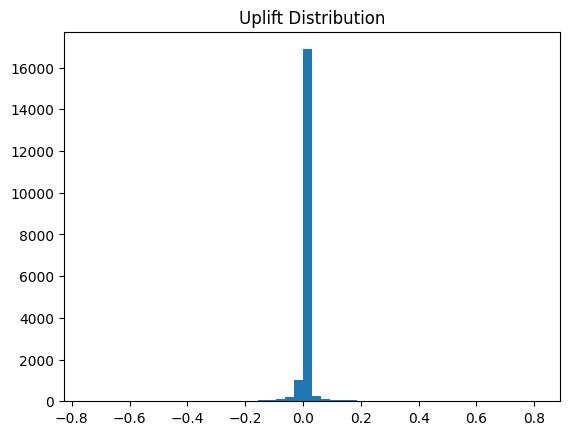

In [31]:
import matplotlib.pyplot as plt

plt.hist(uplift, bins=50)
plt.title("Uplift Distribution")
plt.show()

In [32]:
top_users['conversion'].mean()

np.float64(0.009114583333333334)

In [33]:
print((pd.Series(uplift) > 0).sum() )  # positive users
print((pd.Series(uplift) < 0).sum() )  # negative users
print((pd.Series(uplift) == 0).sum())  # neutral users

2894
1561
14745


The uplift model identifies users who are most likely to respond positively to email campaigns.
By targeting only high-uplift users, the company can improve conversion rates while reducing unnecessary communication costs.
This approach enables personalized marketing and maximizes return on investment.